# 03 — Monte Carlo del portafoglio

10.000 path, 70 giorni di borsa (≈ metà luglio → metà ottobre). Modello: GBM con innovazioni **Student-t (df=4, fat tails)**, correlazione SPCX-GOOGL ρ=0.45, **jump log-normale al giorno dell'evento** (trimestrale+sblocco insider, default -8% ± 12%). Lo spread ha hard cap matematico: il test lo verifica su ogni path.

In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from src.viz import tufte_style, direct_label_lines, corr_heatmap, pnl_distribution, PALETTE
tufte_style()

In [2]:
from src.risk.montecarlo import McConfig, SpreadPosition, simulate, report
cfg, spread = McConfig(), SpreadPosition()
res = simulate(cfg, spread)
max_loss_spread = spread.debit * 100 * spread.contracts / 1.08
assert res["pnl_spread_eur"].min() >= -max_loss_spread - 1e-6, "HARD CAP VIOLATO"
rep = report(res)
pd.Series(rep).round(1)

mean              73.0
median            86.4
VaR95            320.5
ES95             392.1
p_loss             0.4
p_loss_gt_200      0.1
best_5pct        448.5
worst_path      -633.7
dtype: float64

## Distribuzione P&L totale con VaR/ES annotati

Il grafico che Aladdin mostra per ogni portafoglio: non un numero, la **forma** del rischio. Coda destra corta (gain cappato dallo spread), coda sinistra lunga (GOOGL senza hard cap).

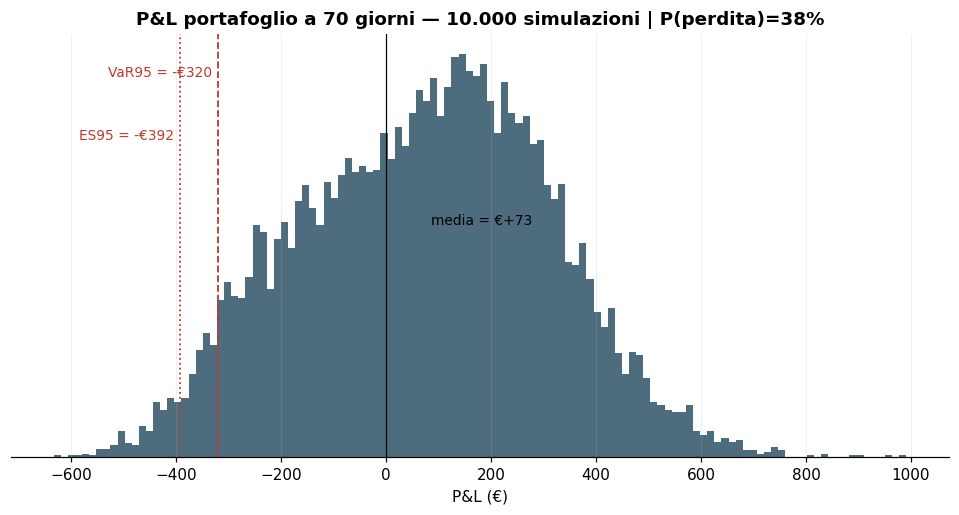

In [3]:
fig, ax = plt.subplots(figsize=(11, 5))
pnl_distribution(ax, res["pnl_total_eur"], rep["VaR95"], rep["ES95"],
                 f"P&L portafoglio a 70 giorni — 10.000 simulazioni | P(perdita)={rep['p_loss']:.0%}")
fig.savefig("../data/chart_mc_pnl.png", bbox_inches="tight"); plt.show()

## Payoff dello spread a scadenza + dove finiscono i path simulati

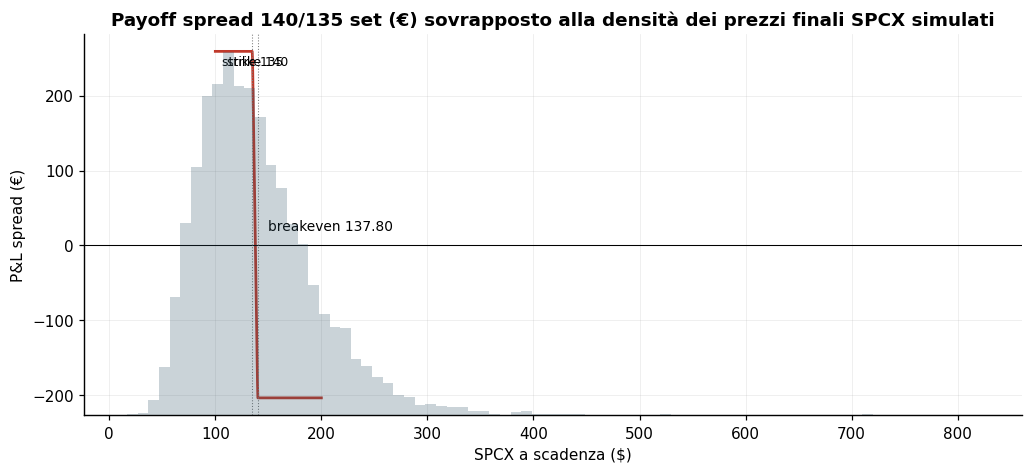

In [4]:
grid = np.linspace(100, 200, 300)
payoff_eur = spread.payoff(grid) / 1.08
fig, ax = plt.subplots(figsize=(11, 4.5))
ax2 = ax.twinx()
ax2.hist(res["spcx_final"], bins=80, color=PALETTE[0], alpha=0.25)
ax2.set_yticks([]); ax2.spines["right"].set_visible(False)
ax.plot(grid, payoff_eur, lw=1.8, color=PALETTE[1])
ax.axhline(0, color="black", lw=0.7)
for s, lbl in [(spread.short_strike, "strike 135"), (spread.long_strike, "strike 140")]:
    ax.axvline(s, color="gray", lw=0.7, ls=":")
    ax.annotate(lbl, (s, ax.get_ylim()[1]*0.85), fontsize=8, ha="center")
be = spread.long_strike - spread.debit
ax.annotate(f"breakeven {be:.2f}", (be, 0), xytext=(8, 10), textcoords="offset points", fontsize=9)
ax.set_title("Payoff spread 140/135 set (€) sovrapposto alla densità dei prezzi finali SPCX simulati")
ax.set_xlabel("SPCX a scadenza ($)"); ax.set_ylabel("P&L spread (€)")
fig.savefig("../data/chart_payoff.png", bbox_inches="tight"); plt.show()

## Sensitività: il P&L medio in funzione del jump dell'evento

La colonna vertebrale della decisione: la strategia vive o muore sull'ampiezza del jump di agosto. Tutto il resto è rumore.

In [5]:
from dataclasses import replace
rows = []
for jm in [-0.20, -0.15, -0.10, -0.08, -0.05, 0.0, 0.05]:
    r = report(simulate(replace(cfg, jump_mean=jm, seed=11), spread))
    rows.append({"jump_evento": f"{jm:+.0%}", "P&L medio €": round(r["mean"]), "P(perdita)": f"{r['p_loss']:.0%}", "VaR95 €": round(r["VaR95"]), "ES95 €": round(r["ES95"])})
sens = pd.DataFrame(rows).set_index("jump_evento")
sens

,P&L medio €,P(perdita),VaR95 €,ES95 €
jump_evento,,,,
-20%,127,28%,274,347
-15%,102,32%,295,367
-10%,78,37%,313,385
-8%,68,39%,321,393
-5%,53,42%,331,401
+0%,31,45%,345,414
+5%,9,50%,356,425


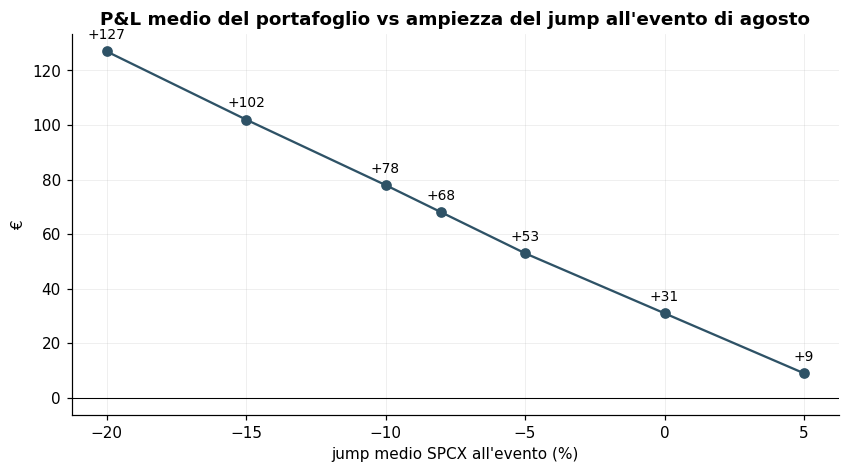

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.5))
x = [-20, -15, -10, -8, -5, 0, 5]
y = sens["P&L medio €"].values
ax.plot(x, y, marker="o", lw=1.5)
ax.axhline(0, color="black", lw=0.7)
for xi, yi in zip(x, y):
    ax.annotate(f"{yi:+.0f}", (xi, yi), xytext=(0, 8), textcoords="offset points", ha="center", fontsize=9)
ax.set_title("P&L medio del portafoglio vs ampiezza del jump all'evento di agosto")
ax.set_xlabel("jump medio SPCX all'evento (%)"); ax.set_ylabel("€")
fig.savefig("../data/chart_sensitivity.png", bbox_inches="tight"); plt.show()

## Conclusioni operative

1. L'hard cap dello spread regge su 10.000 path: la perdita oltre ~€400 viene solo da GOOGL (beta mercato), mai dal derivato.
2. EV positivo richiede jump evento ≤ -5%: coerente con la soglia P≥44% del file 02.
3. La coda sinistra (ES95) è dominata dalla tranche A: chi volesse ridurla taglia GOOGL, non lo spread.
4. **Aggiornare i parametri con i dati reali** appena SPCX quota: `spcx_s0`, `spcx_vol` (dalla IV delle opzioni), `debit` reale. I default sono le stime del file 02.